In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

(X_train,y_train) , (X_test,y_test) = keras.datasets.mnist.load_data()

In [2]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)


5


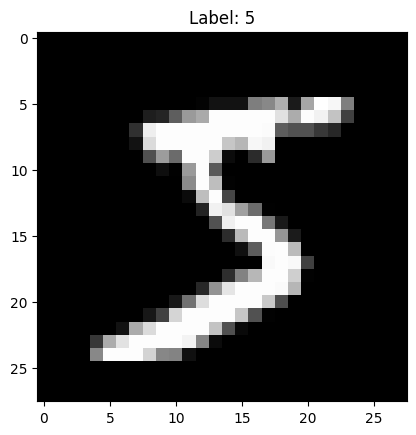

In [3]:
print(y_train[0])
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
print(X_train.min() , X_train.max())

0.0 1.0


In [6]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\Heel\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9238 - loss: 0.2686 - val_accuracy: 0.9660 - val_loss: 0.1201
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9645 - loss: 0.1205 - val_accuracy: 0.9693 - val_loss: 0.1024
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9754 - loss: 0.0826 - val_accuracy: 0.9765 - val_loss: 0.0773
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9811 - loss: 0.0629 - val_accuracy: 0.9775 - val_loss: 0.0745
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9848 - loss: 0.0482 - val_accuracy: 0.9795 - val_loss: 0.0727


In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9788 - loss: 0.0724
Test accuracy: 0.9787999987602234


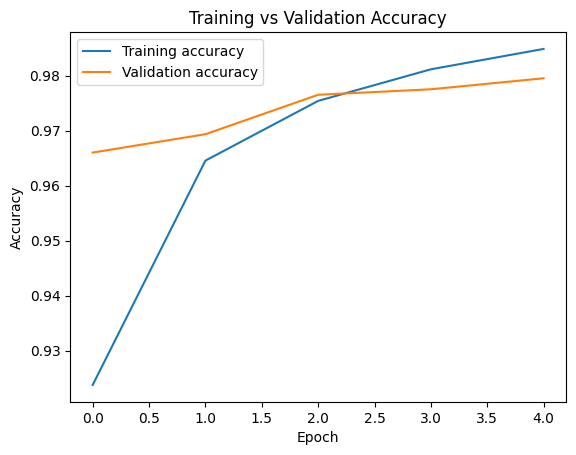

In [10]:
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

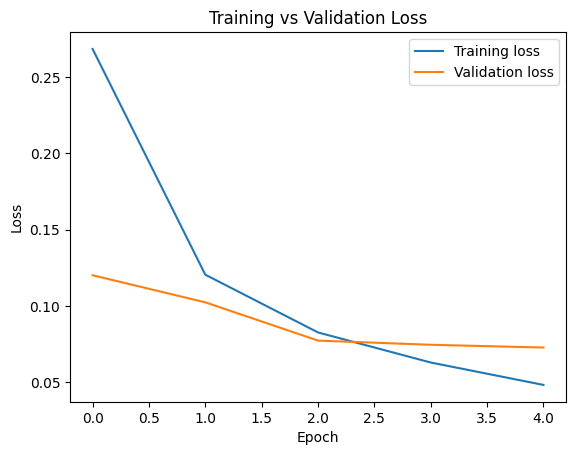

In [11]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model says: 7
Real label: 7


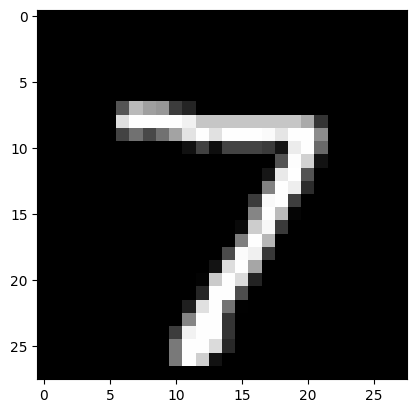

In [13]:
import numpy as np

predictions = model.predict(X_test)

print("Model says:", np.argmax(predictions[0]))
print("Real label:", y_test[0])

plt.imshow(X_test[0], cmap='gray')
plt.show()